# Gradients Computation Notebook

This notebook pcomputes functional gradients using connectivity-based methods. 
It does **not** accurately reflect volume conduction effects but provides a basic approach for plotting EEG 
data to the cortical surface **without requiring imaging or FreeSurfer outputs**.

### Workflow:
1. **Plot EEG Data on the Surface**  
   - Use a standard **61-electrode (2010 notation) parcellation**.  
   - Map the electrodes to **fsaverage 5 space** for visualization.

2. **Compute Gradients with EEG Data**  
   - Construct a connectivity matrix (e.g., **coherence-based**).  
   - **Regress out geodesic distance** from the connectivity matrix using a linear model.  
   - Compute both **geodesic distance** and **Euclidean distance** to analyze spatial relationships.

This notebook provides a structured and adaptable pipeline for EEG-based gradient analysis, enabling further exploration of spatial-functional brain organization.

March 2025,  Marian Simarro gonzalez@cbs.mpg.de , Clara Weber webercl@cbs.mpg.de 


In [88]:
# housekeeping
import sys
import numpy as np
import pandas as pd 
import mne
import numpy as np
from nilearn import plotting
import scipy.io as sio
from brainspace.mesh import mesh_io
from brainspace.plotting import plot_hemispheres
from brainspace.datasets import load_fsa5
from brainstat.datasets import fetch_parcellation
from brainspace.gradient import GradientMaps
import os
from scipy.spatial.distance import cdist
import nibabel as nib
from nilearn.datasets import fetch_surf_fsaverage
from mne.channels import make_standard_montage
from mne.io import read_raw_eeglab
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

os.chdir("/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/")  # Change to your actual folder where little_helpers.py and config.py files are
sys.path.append(os.getcwd())  # Ensure the current directory is added to the path

from little_helpers import load_data, visualize_matrices
import config
from config import subjects_list, conditions, matrix_type, con_folder, corr_folder, input_folder, original_ch_names


# Map surface

In [89]:

# get eeg data labels (here from LEMON dataset)
data = read_raw_eeglab('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/subjects/sub-032304_EO.set')
lemon_ch_names = data.ch_names

# get eeg electrode coordinates
montage = make_standard_montage('standard_1020')

# or choose from other montages 
#mne.channels.get_builtin_montages()

# Get the 3D positions of electrodes
pos_3d = np.array([montage.get_positions()['ch_pos'][ch] for ch in lemon_ch_names])*1000

# Fetch fsaverage surface using nilearn
fsaverage = fetch_surf_fsaverage()

# Load the surface files
surf_lh = mesh_io.read_surface(fsaverage['pial_left'])
surf_rh = mesh_io.read_surface(fsaverage['pial_right'])
vertices_lh = surf_lh.GetPoints()
vertices_rh = surf_rh.GetPoints()

# Find closest electrode for each vertex
distances_lh = cdist(vertices_lh, pos_3d)
closest_electrode_lh = np.argmin(distances_lh, axis = 1) + 1
distances_rh = cdist(vertices_rh, pos_3d)
closest_electrode_rh = np.argmin(distances_rh, axis = 1) + 1

parcellation = np.concatenate((closest_electrode_lh, closest_electrode_rh))
np.save('closest_parcellation_fsa5_eeg2010.npy', parcellation)

# load surface and schaefer parcellation for midline mask
surf_lh, surf_rh = load_fsa5()
s200 = fetch_parcellation('fsaverage5', 'schaefer',200, join=True)
mask = s200 ==0

/tmp/ipykernel_46610/4074863186.py:2: RuntimeWarning: Data file name in EEG.data (sub-010005_EO.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-032304_EO.fdt).
  data = read_raw_eeglab('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/subjects/sub-032304_EO.set')
/tmp/ipykernel_46610/4074863186.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  data = read_raw_eeglab('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/subjects/sub-032304_EO.set')
/tmp/ipykernel_46610/4074863186.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data = read_raw_eeglab('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/subjects/sub-032304_EO.set')


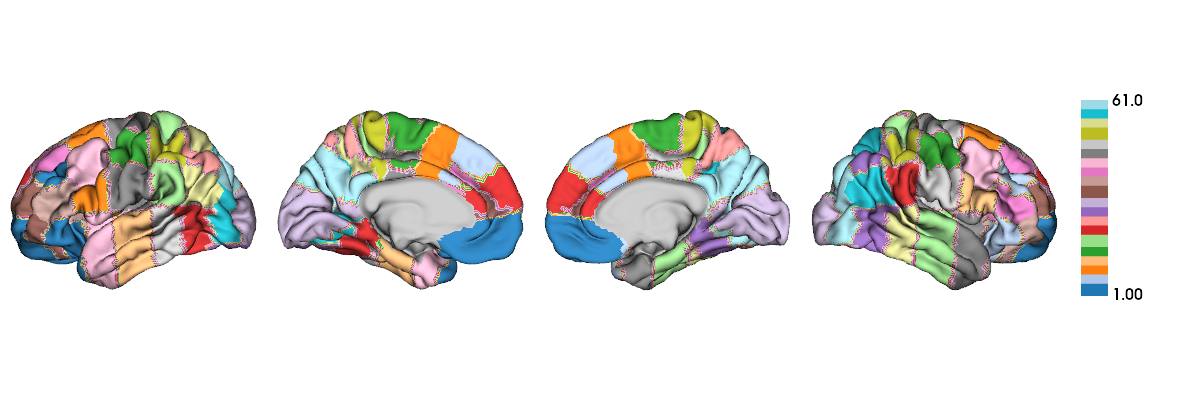

In [90]:
# also can load fsa5 surface from brainspace here because it looks smoother :)
#surf_lh, surf_rh = load_fsa5()
plot_parcels = np.asarray(parcellation, dtype ='f')
plot_parcels[mask] = np.nan
plot_hemispheres(
    surf_lh, 
    surf_rh, 
    plot_parcels, 
    size=(1200, 400), 
    nan_color=(0.7,0.7,0.7,1), 
    zoom = 1.2, 
    cmap='tab20', 
    color_bar=True, 
    embed_nb = True)


In [91]:
# create dataframe as dictionary between parcel # and EEG electrode
if len(lemon_ch_names)==61:
    lemon_ch_names.insert(0, 'midline mask')
df = pd.DataFrame({'electrode no': lemon_ch_names, 'parcels': range(0,62)})
df.to_csv('electrodename_parcel_dict_61.csv')

In [92]:
# %%
parcels_2 = np.load('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/Gradients/closest_parcellation.npy')
parcels_3 = np.load('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/Gradients/closest_parcellation.npy')
parcels_4 = np.load('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/Gradients/closest_parcellation.npy')
parcels_5 = np.load('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/Gradients/closest_parcellation.npy')
parcels_2[parcels_2 != 5] = 0
parcels_3[parcels_3 != 14] = 0
parcels_4[parcels_4 != 24] = 0
parcels_5[parcels_5 != 59] = 0
arr = [parcels_2, parcels_3, parcels_4, parcels_5]
plot_hemispheres(surf_lh, surf_rh, arr, size=(1200, 800), zoom = 1.2, cmap='tab20', color_bar=True, embed_nb = True)


# Plot EEG data on surface
def map_to_labels(in_eeg, labels = parcellation):
    """
    this function takes a vector of EEG data and maps it to the cortical surface
    here 56 channel data is considered
    in_eeg = one dimensional (shape 56,) numpy array of eeg data
    out_data = mapped to 20484 vertices of fsaverage5 surface
    """
    out_data = np.empty((20484,))

    for i in range(len(np.unique(labels))):
        out_data[labels == i+1] = in_eeg[i]

    return out_data


In [123]:
# Create output directory for plots
gradients_folder = "/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/Gradients/"
con_folder = "/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/"
# load avg matrices
ec_avg_matrix = np.load(os.path.join(con_folder, 'ec_avg_matrix_filled_beta.npy'))
eo_avg_matrix = np.load(os.path.join(con_folder, 'eo_avg_matrix_filled_beta.npy'))

In [124]:
mat = eo_avg_matrix
print(mat)

[[0.         0.62529827 0.72281371 ... 0.26687812 0.28083437 0.34885986]
 [0.62529827 0.         0.56580344 ... 0.25450442 0.28312784 0.35439416]
 [0.72281371 0.56580344 0.         ... 0.33609454 0.33076339 0.38313607]
 ...
 [0.26687812 0.25450442 0.33609454 ... 0.         0.93660832 0.82118244]
 [0.28083437 0.28312784 0.33076339 ... 0.93660832 0.         0.93335546]
 [0.34885986 0.35439416 0.38313607 ... 0.82118244 0.93335546 0.        ]]


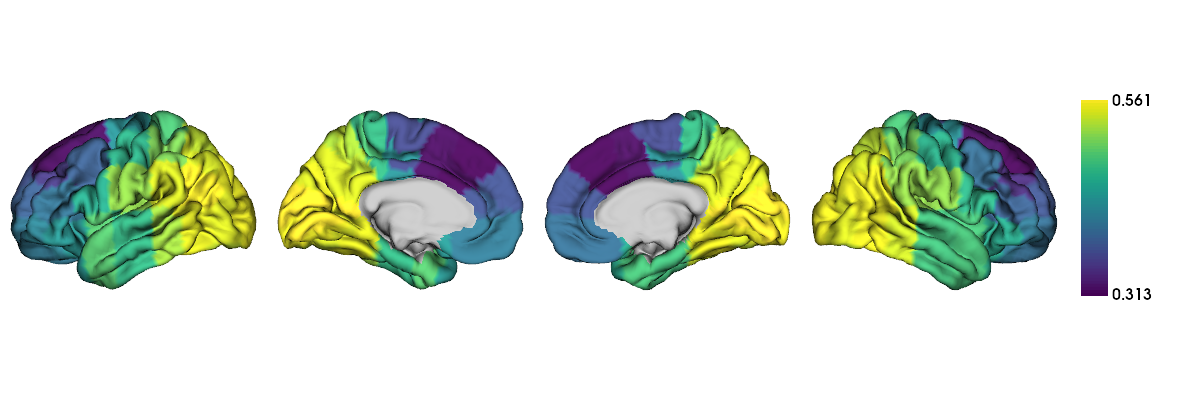

In [125]:
matt = map_to_labels(np.mean(mat, axis = 0))
matt[mask] = np.nan # remove midline zeros

plot_hemispheres(surf_lh, surf_rh, 
    matt, 
    size = (1200, 400), 
    nan_color = (0.7, 0.7, 0.7, 1),  
    zoom = 1.2, 
    cmap='viridis', 
    color_bar = True, 
    embed_nb = True, 
    #color_range=(-0.75, 0.75) # adjust this to your data!
    )

## EO avg gradient

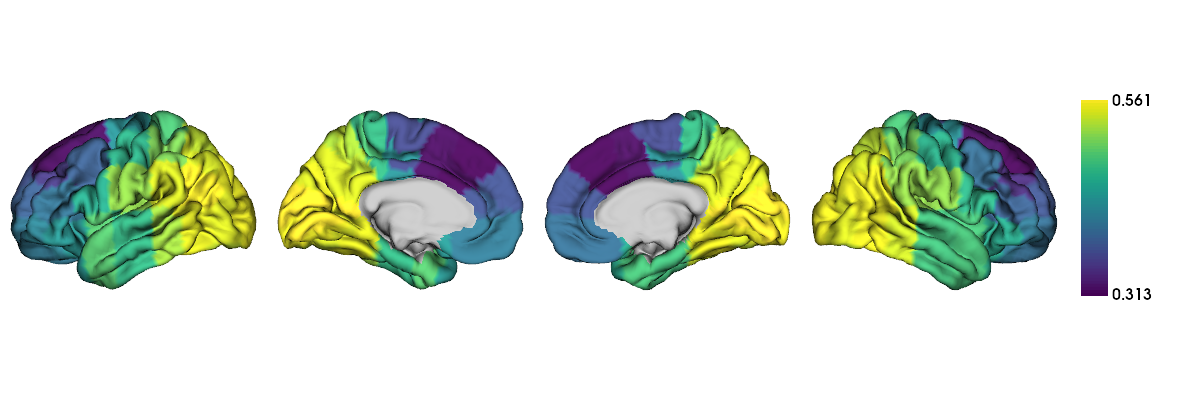

In [126]:
eeg_mapped_EO = map_to_labels(np.mean(eo_avg_matrix, axis = 0))
eeg_mapped_EO[mask] = np.nan # remove midline zeros

plot_hemispheres(
    surf_lh, surf_rh, 
    eeg_mapped_EO, 
    size = (1200, 400), 
    nan_color = (0.7, 0.7, 0.7, 1),  
    zoom = 1.2, 
    cmap='viridis', 
    color_bar = True, 
    embed_nb = True, 
    #color_range=(-0.75, 0.75) # adjust this to your data!
    )

In [127]:
# ## Gradient

# 1. First ensure your connectivity matrix is properly formed
# If 'matrix' is your correlation/coherence matrix between channels
# It should be square (N×N where N is your number of channels)

# Check matrix shape and handle NaN values
print("Matrix shape:", eo_avg_matrix.shape)
if np.isnan(eo_avg_matrix).any():
    print("Warning: NaN values in matrix")
    matrix = np.nan_to_num(eo_avg_matrix)  # Replace NaNs before processing

# 2. Compute gradients on the connectivity matrix directly
gm = GradientMaps(kernel='pearson', approach='dm', random_state=0)
gm.fit(eo_avg_matrix)  # Matrix should be channel × channel

# 3. Get the first few gradients
gradients = gm.gradients_[:, :3]  # First 3 gradients
print("Gradient shapes:", gradients.shape)

# 4. Now map these gradients to the cortical surface
mapped_gradients = []

for i in range(gradients.shape[1]):
    grad_mapped = map_to_labels(gradients[:, i], parcellation)  # Add target labels
    grad_mapped[mask] = np.nan  # Apply mask
    mapped_gradients.append(grad_mapped)

# 5. Visualize the mapped gradients
p = plot_hemispheres(surf_lh, surf_rh, 
                 array_name=mapped_gradients, 
                 size=(1200, 700), 
                 nan_color=(0.7, 0.7, 0.7, 1),
                 zoom=1.2, 
                 cmap= ['viridis_r', 'PRGn', 'PuOr'],
                 color_bar=True,
                 embed_nb=False, 
                 label_text=['Gradient 1', 'Gradient 2', 'Gradient 3'],
                 color_range=[(-20, 30),(-15,15), (-10,10)],
                 screenshot = True,
                 filename = "eo_avg_matrix_beta.png"
                 )

Matrix shape: (61, 61)
Gradient shapes: (61, 3)


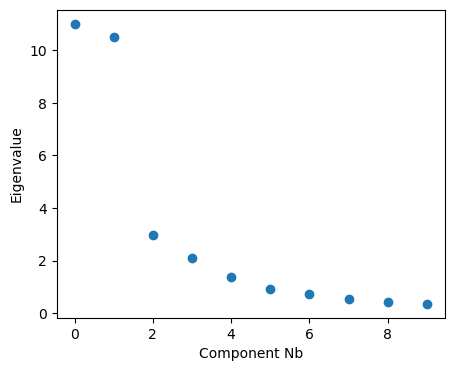

In [121]:
fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm.lambdas_.size), gm.lambdas_)
ax.set_xlabel('Component Nb')
ax.set_ylabel('Eigenvalue')

plt.show()

# EC avg gradient

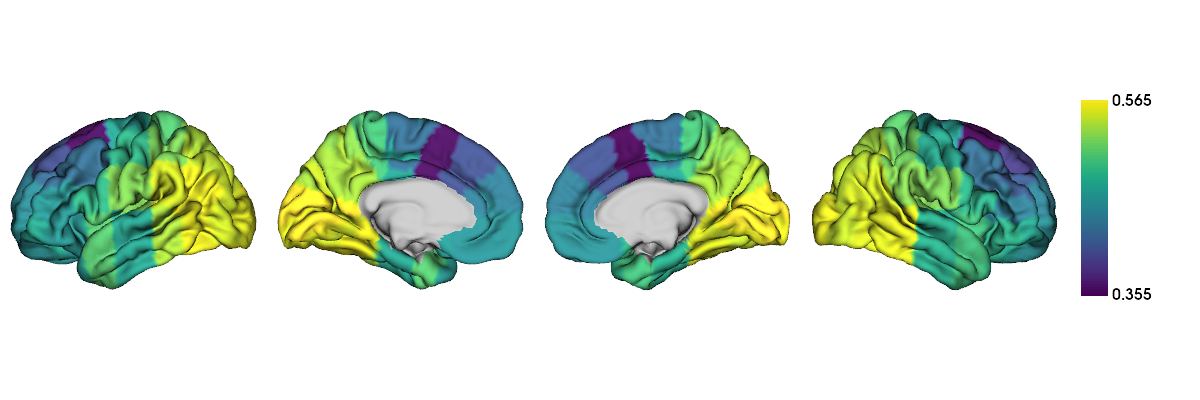

In [57]:
eeg_mapped_EC = map_to_labels(np.mean(ec_avg_matrix, axis = 0))
eeg_mapped_EC[mask] = np.nan # remove midline zeros

# %%
plot_hemispheres(
    surf_lh, surf_rh, 
    eeg_mapped_EC, 
    size = (1200, 400), 
    nan_color = (0.7, 0.7, 0.7, 1),  
    zoom = 1.2, 
    cmap='viridis', 
    color_bar = True, 
    embed_nb = True, 
    #color_range=(-0.75, 0.75) # adjust this to your data!
    )

In [58]:
# ## Gradient

# 1. First ensure your connectivity matrix is properly formed
# If 'matrix' is your correlation/coherence matrix between channels
# It should be square (N×N where N is your number of channels)

# Check matrix shape and handle NaN values
print("Matrix shape:", ec_avg_matrix.shape)
if np.isnan(ec_avg_matrix).any():
    print("Warning: NaN values in matrix")
    matrix_ec = np.nan_to_num(ec_avg_matrix)  # Replace NaNs before processing

# 2. Compute gradients on the connectivity matrix directly
gm_ec = GradientMaps(kernel='pearson', approach='dm', random_state=0)
gm_ec.fit(ec_avg_matrix)  # Matrix should be channel × channel

# 3. Get the first few gradients
gradients_ec = gm_ec.gradients_[:, :3]  # First 3 gradients
#print("Gradient shapes:", gradients_ec)

# 4. Now map these gradients to the cortical surface
mapped_gradients_ec = []
"""for i in range(gradients.shape[1]):
    grad_mapped = map_to_labels(gradients[:, i])
    grad_mapped[mask] = np.nan  # Apply mask
    mapped_gradients.append(grad_mapped)"""

for i in range(gradients_ec.shape[1]):
    grad_mapped_ec = map_to_labels(gradients_ec[:, i], parcellation)  # Add target labels
    grad_mapped_ec[mask] = np.nan  # Apply mask
    mapped_gradients_ec.append(grad_mapped_ec)

# 5. Visualize the mapped gradients
p_ec = plot_hemispheres(surf_lh, surf_rh, 
                 array_name=mapped_gradients_ec, 
                 size=(1200, 700), 
                 nan_color=(0.7, 0.7, 0.7, 1),
                 zoom=1.2, 
                 cmap='viridis_r', 
                 color_bar=True,
                 embed_nb=False, 
                 label_text=['Gradient 1', 'Gradient 2', 'Gradient 3'],
                 color_range=(-20, 20),
                 screenshot = True,
                 filename = "ec_avg_matrix20.png"
                 )

Matrix shape: (61, 61)


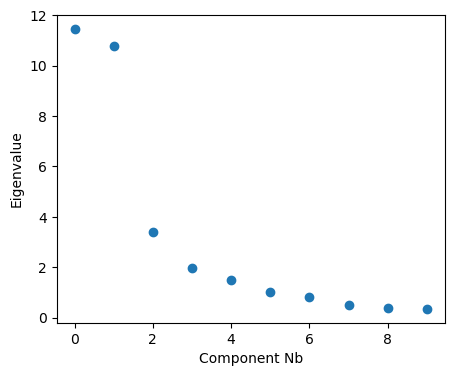

In [59]:
fig, ax = plt.subplots(1, figsize=(5, 4))
ax.scatter(range(gm.lambdas_.size), gm.lambdas_)
ax.set_xlabel('Component Nb')
ax.set_ylabel('Eigenvalue')

plt.show()

# geodesic distance

In [60]:
lh_dist = nib.load('/data/hu_gonzalez/Downloads/fsa5.L.dconn.nii').get_fdata()
rh_dist = nib.load('/data/hu_gonzalez/Downloads/fsa5.R.dconn.nii').get_fdata()

In [61]:
geodesic_distances = np.concatenate((lh_dist, rh_dist), axis=0)

In [62]:
mean_distance = np.mean(geodesic_distances, axis=1)

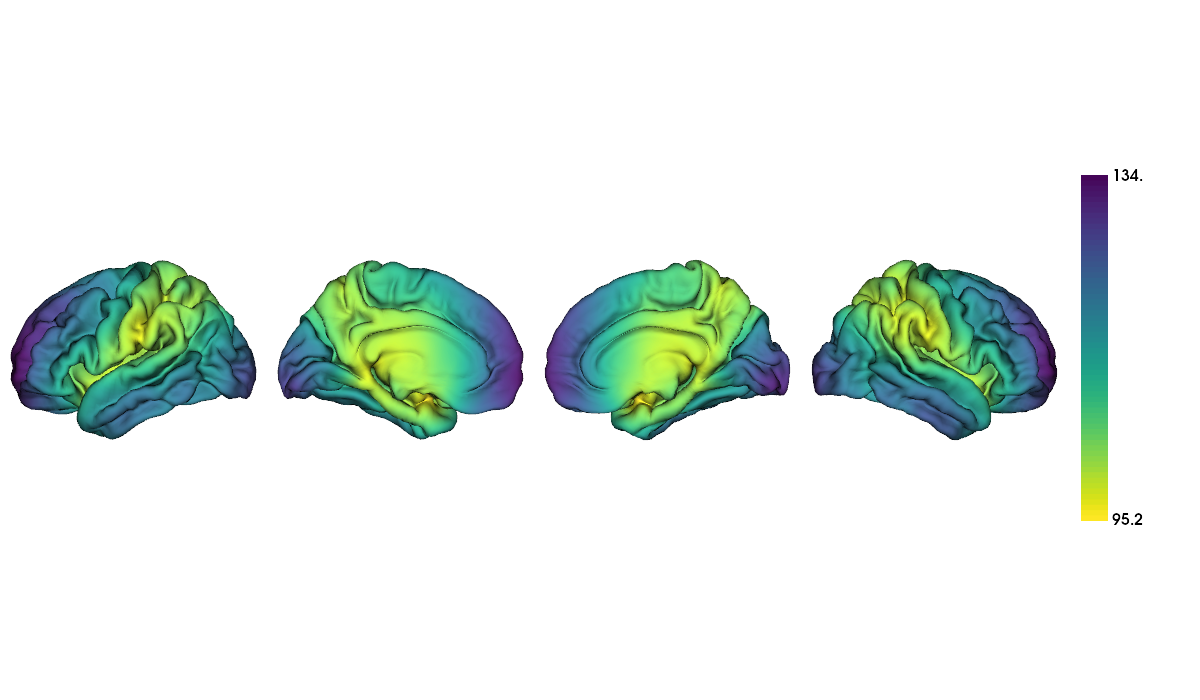

In [63]:
plot_hemispheres(surf_lh, surf_rh, 
                 array_name=mean_distance, 
                 size=(1200, 700), 
                 nan_color=(0.7, 0.7, 0.7, 1),
                 zoom=1.2, 
                 cmap='viridis_r', 
                 color_bar=True,
                 embed_nb=True, 
                 )

Shape of concatenated geodesic distance map: (20484, 10242)


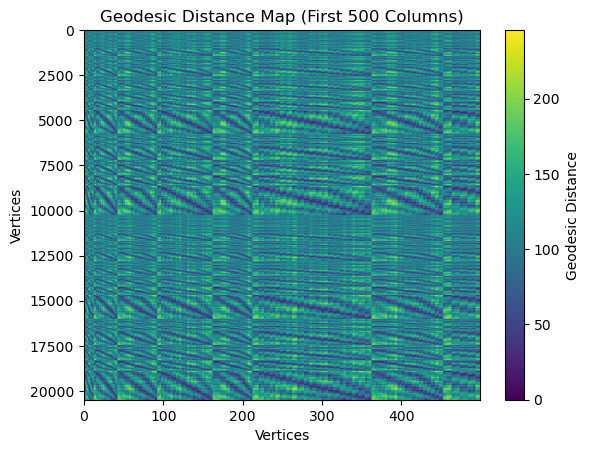

In [64]:
# Check the shape of the data
print("Shape of concatenated geodesic distance map:", geodesic_distances.shape)

# Visualize a slice of the matrix
plt.imshow(geodesic_distances[:, :500], aspect='auto', cmap='viridis')  
plt.colorbar(label="Geodesic Distance")  
plt.title("Geodesic Distance Map (First 500 Columns)")
plt.xlabel("Vertices")
plt.ylabel("Vertices")
plt.show()


In [ ]:
# Load coherence matrix and parcellation
coherence_matrix = eo_avg_matrix
num_parcels = coherence_matrix.shape[0]  # Should be 56x56

# Initialize array to store mean distances
parcel_mean_distances = np.zeros(num_parcels)

for parcel in range(num_parcels):
    # Get connectivity values for the current parcel
    parcel_connections = coherence_matrix[parcel, :]
    
    # Find the top 10% strongest connections (absolute values)
    threshold = np.percentile(np.abs(parcel_connections), 90)
    strongest_connections = np.where(np.abs(parcel_connections) >= threshold)[0]  # Get parcel indices
    if np.any(strongest_connections == 0):
        strongest_connections = strongest_connections[1:]
    #print(strongest_connections)
    # Compute mean geodesic distance for these strongly connected parcels
    mean_distance = np.mean([np.mean(geodesic_distances[parcellation == p]) for p in strongest_connections])
    # print(mean_distance)
    parcel_mean_distances[parcel] = mean_distance

# Load fsaverage5 surface
surf_lh, surf_rh = load_fsa5()

# Map values back to voxels for visualization
mapped_data = np.zeros_like(parcellation, dtype=float)
for i in range(num_parcels):
    mapped_data[parcellation == i+1] = parcel_mean_distances[i]
print(parcel_mean_distances)
# Plot results
# load surface and schaefer parcellation for midline mask
s200 = fetch_parcellation('fsaverage5', 'schaefer',200, join=True)
mask = s200 ==0
mapped_data[mask] = np.nan
plot_hemispheres(surf_lh, surf_rh, mapped_data, 
                 size=(1200, 400), 
                 nan_color=(0.7, 0.7, 0.7, 1), 
                 zoom=1.2,
                 cmap= ['viridis_r', 'PRGn', 'PuOr'],
                 color_bar=True, 
                 screenshot=True,
                 filename="connectivity_distance_filled.png"
                 )


# linear model

In [20]:
def regress_distance(in_eeg, in_distance):
    """
    Regress out geodesic distance from a connectivity (e.g., coherence) matrix.
    
    Parameters:
    -----------
    in_eeg : numpy array
        Coherence matrix (channels x channels).
    in_distance : numpy array
        Electrode distance matrix (channels x channels).
    
    Returns:
    --------
    residual_matrix : numpy array
        The residual coherence matrix after regressing out distance.
    """
    # Use only the lower triangular part (without the diagonal)
    in_eeg_lt = np.tril(in_eeg, k=1)
    in_distance_lt = np.tril(in_distance, k=1)

    # Flatten and reshape for regression
    x_flat = in_distance_lt.flatten().reshape(-1, 1)
    y_flat = in_eeg_lt.flatten()

    # Fit the linear model: distance --> coherence value
    model = LinearRegression().fit(x_flat, y_flat)
    y_pred = model.predict(x_flat)

    # Residuals: differences between observed and predicted coherence values
    residuals = y_flat - y_pred

    # Reshape residuals back to the original matrix shape (lower triangle)
    residual_matrix = np.zeros_like(y_flat) # residual_matrix = np.zeros_like(in_eeg)
    # Fill the lower triangle with residuals
    # Optionally, mirror the lower triangle to the upper triangle to enforce symmetry
    # residual_matrix = residual_matrix + residual_matrix.T
    residual_matrix = residuals.reshape(61,61)
    print(residual_matrix)
    return residual_matrix


In [21]:
# pos_3d is an array of electrode 3D positions (in mm)
electrode_distance_matrix = squareform(pdist(pos_3d))

# electrode_distance_matrix is a square matrix where each entry is the Euclidean distance between a pair of electrodes.
# Note: If you want to use true geodesic distances along the cortical surface, you’d need to compute that separately. 
# The code below assumes electrode distances are acceptable proxies.

In [ ]:
# Regress out the electrode distance from the coherence matrix
residual_coherence = regress_distance(eo_avg_matrix, electrode_distance_matrix)

# Optional: Save the residual matrix for later inspection
np.save('/data/tu_gonzalez/MPI-Leipzig-Mind-Brain-Body/Results/connectivity/eo_residual_coherence.npy', residual_coherence)


[[-0.10533207  0.33629559 -0.10533207 ... -0.10533207 -0.10533207
  -0.10533207]
 [ 0.33629559 -0.10533207  0.18252654 ... -0.10533207 -0.10533207
  -0.10533207]
 [ 0.44975988  0.18252654 -0.10533207 ... -0.10533207 -0.10533207
  -0.10533207]
 ...
 [-0.28567955 -0.29190905 -0.20076835 ... -0.10533207  0.74952386
  -0.10533207]
 [-0.28600043 -0.26215945 -0.22903324 ...  0.74952386 -0.10533207
   0.74022569]
 [-0.23872457 -0.20071084 -0.1971383  ...  0.55724344  0.74022569
  -0.10533207]]


In [ ]:
# Compute gradients on the residual coherence matrix
gm = GradientMaps(kernel='pearson', approach='dm', random_state=0)
gm.fit(residual_coherence)  # Make sure the matrix is channels x channels

# Get the first few gradients (e.g., first three)
residual_gradients = gm.gradients_[:, :3]
print("Residual gradients shape:", residual_gradients.shape)


Residual gradients shape: (61, 3)


In [72]:
mapped_residual_gradients = []
for i in range(residual_gradients.shape[1]):
    grad_mapped = map_to_labels(residual_gradients[:, i], parcellation)  
    grad_mapped[mask] = np.nan  # Apply midline mask if needed
    mapped_residual_gradients.append(grad_mapped)

# Visualize the mapped residual gradients
p = plot_hemispheres(
    surf_lh, surf_rh, 
    array_name=mapped_residual_gradients, 
    size=(1200, 700), 
    nan_color=(0.7, 0.7, 0.7, 1),
    zoom=1.2, 
    cmap= ['viridis_r', 'PRGn', 'PuOr'],
    color_bar=True,
    label_text=['Res Grad 1', 'Res Grad 2', 'Res Grad 3'],
    color_range=[(-20, 30), (-15, 15), (-10, 10)],
    screenshot=True,
    filename="eo_residual_gradient.png"
)


# Euclidian distance

In [ ]:
# Compute Euclidean distances between all EEG electrodes
euclidean_distances = cdist(pos_3d, pos_3d, metric='euclidean')

""""
cdist(pos_3d, pos_3d): Computes the pairwise Euclidean distances between all points in pos_3d.

np.mean(edist, axis=0): Takes the mean Euclidean distance for each point.

map_to_labels(...): Maps the mean distance values onto a set of labels, presumably corresponding to brain parcellation.
"""
edist = np.asarray(cdist(pos_3d, pos_3d))
edist_map = map_to_labels(np.mean(edist, axis=0))


[[  0.          59.31714449  58.34303025 ... 197.04866085 201.01204861
  200.73519983]
 [ 59.31714449   0.         108.83696994 ... 198.0001749  190.89052617
  184.59549684]
 [ 58.34303025 108.83696994   0.         ... 172.44993372 185.16637777
  188.90818762]
 ...
 [197.04866085 198.0001749  172.44993372 ...   0.          39.25290884
   73.40194264]
 [201.01204861 190.89052617 185.16637777 ...  39.25290884   0.
   38.73634327]
 [200.73519983 184.59549684 188.90818762 ...  73.40194264  38.73634327
    0.        ]]


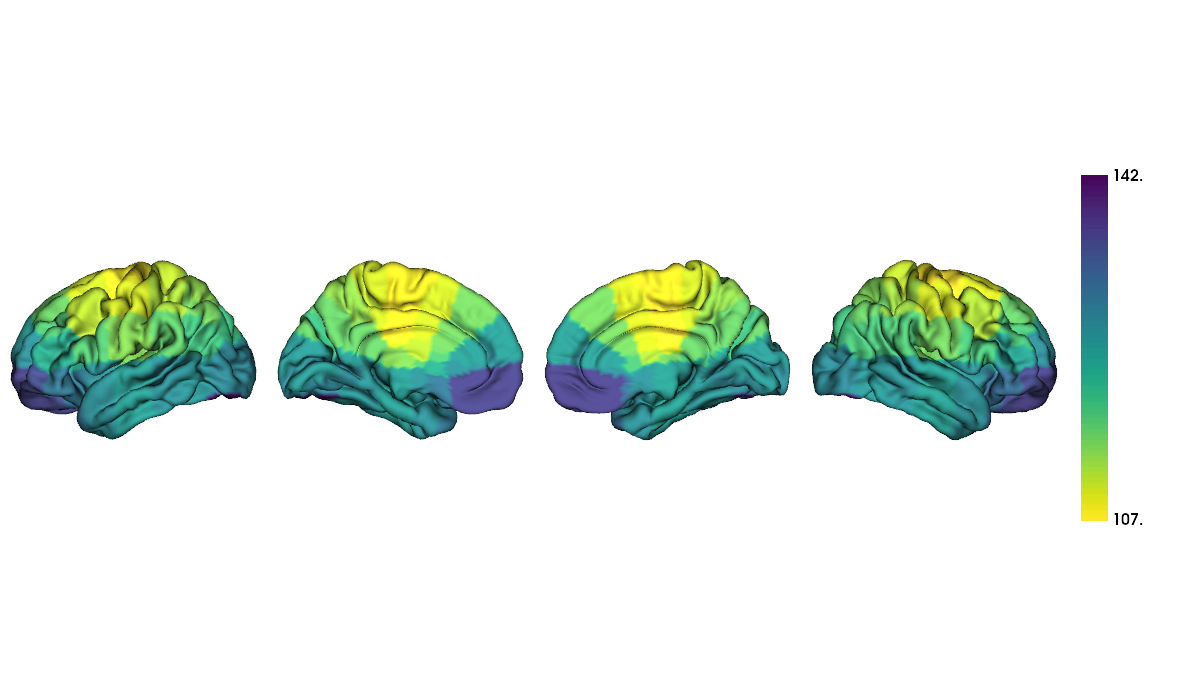

In [ ]:
plot_hemispheres(surf_lh, surf_rh, 
                 array_name=edist_map, 
                 size=(1200, 700), 
                 nan_color=(0.7, 0.7, 0.7, 1),
                 zoom=1.2, 
                 cmap='viridis_r', 
                 color_bar=True,
                 embed_nb=True, 
                 )